<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondAI-2025/blob/main/Aryan%20Basnet%2C%20Arnav%20Maharjan%20and%20Ashila%20A%20M%20Ardiyansyah/AA_master_analysis_all_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NOTE ON RUNTIME AND OUTPUTS**

# Google Colab may have disconnected or reset the runtime during long training sessions, crashes, or memory interruptions. When this occurred, some previously displayed outputs in the notebook were no longer visible. However, all results remained saved and logged correctly. Each model’s complete metrics and metadata were stored as JSON files in my Google Drive folder:

# [https://drive.google.com/drive/folders/1ejlJaZhHEBm-1khLBJ--mbG2pg5TZHoJ?usp=sharing](https://drive.google.com/drive/folders/1ejlJaZhHEBm-1khLBJ--mbG2pg5TZHoJ?usp=sharing)

# These JSON files contain the full and reliable outputs for all models across all datasets, even if certain notebook outputs were lost due to runtime resets.

# **This document consolidates all results from the JSON files generated by executing models across all six datasets. It serves as the central reference for our comparisons and the final conclusions of our research project.**

In [17]:
# Import necessary libraries
from google.colab import drive
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the folder where your X-ray model results are saved
results_folder = "/content/drive/MyDrive/xray_research_results"

# Check if the folder exists
if os.path.exists(results_folder):
    print("Folder found")
    print("Files in folder:", os.listdir(results_folder))
else:
    print("Folder not found. Check the path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder found
Files in folder: ['dataset1_chest_xray_pneumonia_HIC_BaselineCNN_results.json', 'dataset1_chest_xray_pneumonia_HIC_MobileNetV2_results.json', 'dataset1_chest_xray_pneumonia_HIC_EfficientNetB0_results.json', 'dataset1_chest_xray_pneumonia_HIC_ResNet50_results.json', 'dataset3_nigeria_chest_xray_LMIC_BaselineCNN_results.json', 'dataset3_nigeria_chest_xray_LMIC_MobileNetV2_results.json', 'dataset3_nigeria_chest_xray_LMIC_EfficientNetB0_results.json', 'dataset3_nigeria_chest_xray_LMIC_ResNet50_results.json', 'dataset4_chest_xray_LMIC_ResNet50_results.json', 'dataset4_chest_xray_LMIC_MobileNetV2_results.json', 'dataset4_chest_xray_LMIC_EfficientNetB0_results.json', 'dataset4_chest_xray_LMIC_BaselineCNN_results.json', 'checkpoints', 'dataset2_tb_chest_xray_HIC_ResNet50_results.json', 'dataset2_tb_chest_xray_HIC_BaselineCNN_results.json', 'dataset2_tb_c

In [19]:
# Initialize list to hold all results
all_results = []

# Loop through JSON files and extract relevant data
for fname in os.listdir(results_folder):
    if fname.endswith('.json'):
        file_path = os.path.join(results_folder, fname)
        with open(file_path, 'r') as f:
            data = json.load(f)

        dataset = data.get("dataset_name")

        # SKIP dataset_chestxray2017 (the duplicate dataset5)
        if dataset == "dataset_chestxray2017":
            continue

        disease = "TB" if "tb" in dataset.lower() else "Pneumonia"
        income_level = data.get("country_income")
        model = data.get("model_name")
        f1_score = data.get("f1_weighted")
        training_time = data.get("training_time_minutes")

        all_results.append({
            "dataset": dataset,
            "disease": disease,
            "income_level": income_level,
            "model": model,
            "F1_score": f1_score,
            "training_time": training_time
        })

# Updated mapping (dataset6 becomes dataset5)
dataset_labels = {
    "dataset1_chest_xray_pneumonia": "dataset1 - Pneumonia HIC",
    "dataset2_tb_chest_xray": "dataset2 - TB HIC",
    "dataset3_nigeria_chest_xray": "dataset3 - Nigeria LMIC",
    "dataset_tb_chest_xray": "dataset4 - TB LMIC",
    "Bangladesh_chest_xray": "dataset5 - Bangladesh LMIC"  # Changed from dataset6 to dataset5
}

# Create DataFrame
for r in all_results:
    r['dataset'] = dataset_labels.get(r['dataset'], r['dataset'])

df = pd.DataFrame(all_results)

# Updated dataset order (5 datasets instead of 6)
dataset_order = [
    'dataset1 - Pneumonia HIC',
    'dataset2 - TB HIC',
    'dataset3 - Nigeria LMIC',
    'dataset4 - TB LMIC',
    'dataset5 - Bangladesh LMIC'  # Changed from dataset6
]

df['dataset'] = pd.Categorical(df['dataset'], categories=dataset_order, ordered=True)

# Verify datasets present
print("Datasets in analysis:")
print(df['dataset'].unique())

Datasets in analysis:
['dataset1 - Pneumonia HIC', 'dataset3 - Nigeria LMIC', 'dataset4 - TB LMIC', 'dataset2 - TB HIC', 'dataset5 - Bangladesh LMIC']
Categories (5, object): ['dataset1 - Pneumonia HIC' < 'dataset2 - TB HIC' < 'dataset3 - Nigeria LMIC' <
                         'dataset4 - TB LMIC' < 'dataset5 - Bangladesh LMIC']


In [20]:
# To see which datasets are present in the DataFrame

df['dataset'].unique()

['dataset1 - Pneumonia HIC', 'dataset3 - Nigeria LMIC', 'dataset4 - TB LMIC', 'dataset2 - TB HIC', 'dataset5 - Bangladesh LMIC']
Categories (5, object): ['dataset1 - Pneumonia HIC' < 'dataset2 - TB HIC' < 'dataset3 - Nigeria LMIC' <
                         'dataset4 - TB LMIC' < 'dataset5 - Bangladesh LMIC']


F1 Scores for dataset1 - Pneumonia HIC:

disease         Pneumonia
model                    
BaselineCNN      0.775246
EfficientNetB0   0.480769
MobileNetV2      0.877126
ResNet50         0.741086

F1 Scores for dataset2 - TB HIC:

disease               TB
model                   
BaselineCNN     0.956833
EfficientNetB0  0.789555
MobileNetV2     0.980519
ResNet50        0.796047

F1 Scores for dataset3 - Nigeria LMIC:

disease         Pneumonia
model                    
BaselineCNN      0.925311
EfficientNetB0   0.166667
MobileNetV2      0.969494
ResNet50         0.491698

F1 Scores for dataset4 - TB LMIC:

disease               TB
model                   
BaselineCNN     0.982675
EfficientNetB0  0.749832
MobileNetV2     0.912446
ResNet50        0.980554

F1 Scores for dataset5 - Bangladesh LMIC:

disease         Pneumonia
model                    
BaselineCNN      0.900133
EfficientNetB0   0.334417
MobileNetV2      0.927585
ResNet50         0.868014


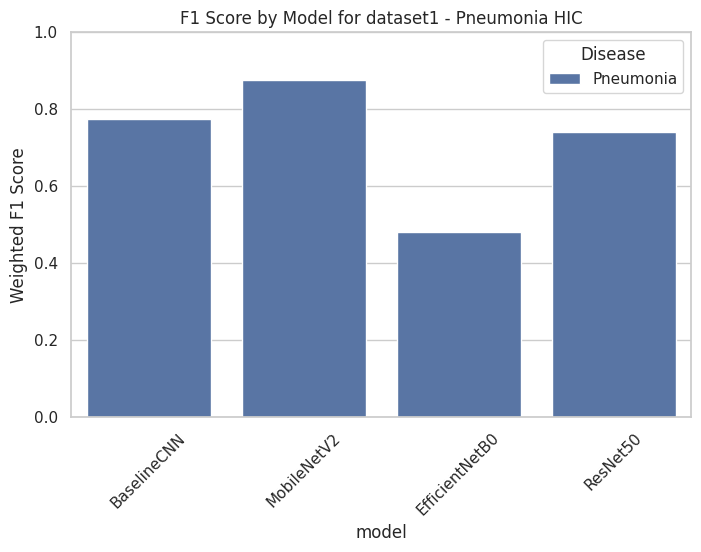

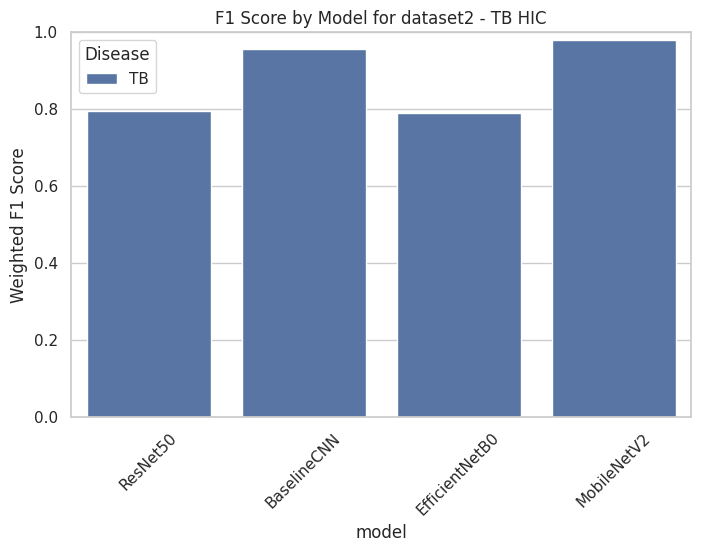

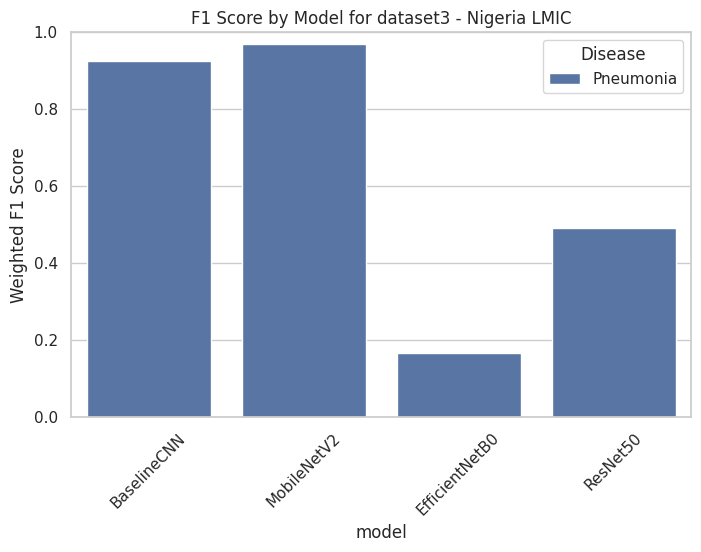

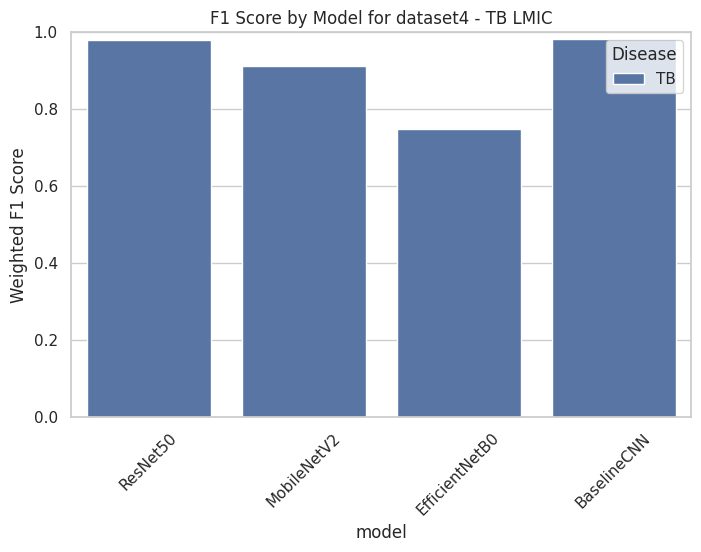

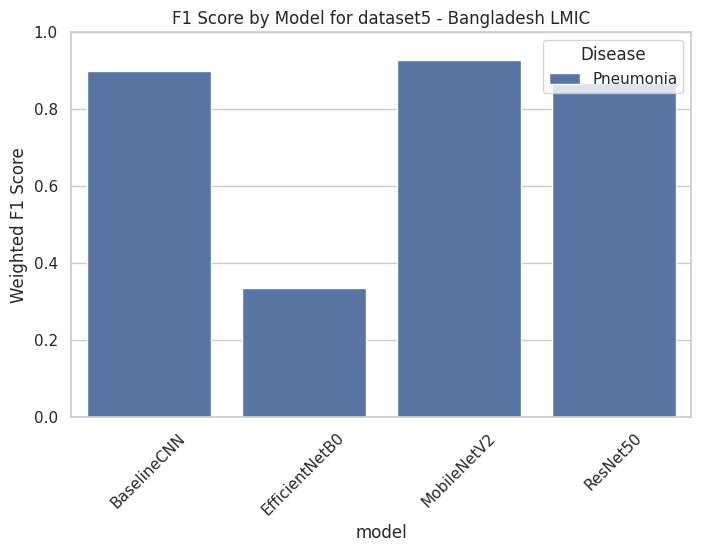

In [21]:
# Block 1 – Bar Chart: F1 Score by Model for Each Dataset

sns.set(style="whitegrid")

# Print tables
for dataset in df['dataset'].cat.categories:
    subset = df[df['dataset'] == dataset]
    table = subset.pivot(index='model', columns='disease', values='F1_score')
    table = table.sort_index()
    print(f"\nF1 Scores for {dataset}:\n")
    print(table.to_string())

# Create bar charts
for dataset in df['dataset'].cat.categories:
    plt.figure(figsize=(8,5))
    subset = df[df['dataset'] == dataset]
    sns.barplot(x='model', y='F1_score', hue='disease', data=subset)
    plt.title(f'F1 Score by Model for {dataset}')
    plt.ylabel('Weighted F1 Score')
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.legend(title='Disease')
    plt.show()

import pandas as pd

/tmp/ipython-input-3513099510.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['income_level', 'model'])['F1_score'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()


HIC vs LMIC F1 Score Comparison:

income_level          model  count     mean   median      min      max
         HIC    BaselineCNN      2 0.866039 0.866039 0.775246 0.956833
         HIC EfficientNetB0      2 0.635162 0.635162 0.480769 0.789555
         HIC    MobileNetV2      2 0.928823 0.928823 0.877126 0.980519
         HIC       ResNet50      2 0.768566 0.768566 0.741086 0.796047
        LMIC    BaselineCNN      3 0.936040 0.925311 0.900133 0.982675
        LMIC EfficientNetB0      3 0.416972 0.334417 0.166667 0.749832
        LMIC    MobileNetV2      3 0.936508 0.927585 0.912446 0.969494
        LMIC       ResNet50      3 0.780088 0.868014 0.491698 0.980554


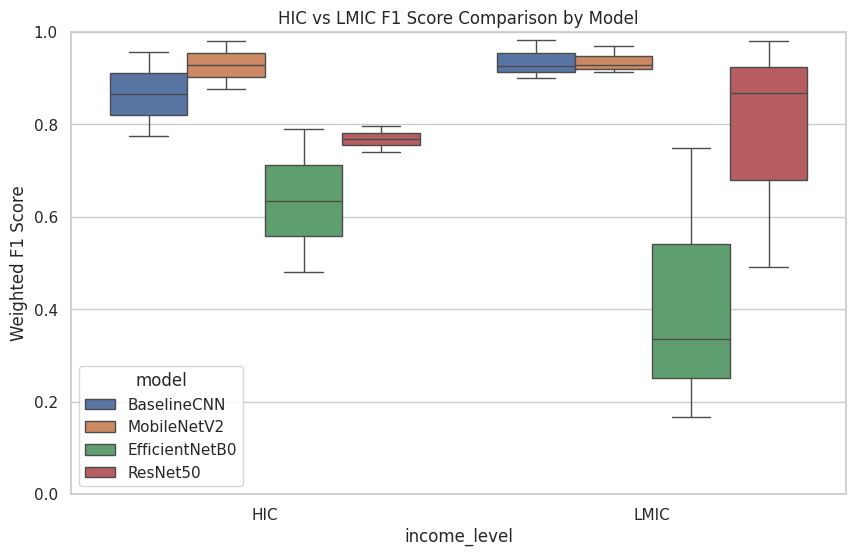

In [22]:
# Block 2 – Boxplot: HIC vs LMIC Comparison

# Ensure consistent categorical ordering
df['income_level'] = pd.Categorical(df['income_level'], categories=['HIC', 'LMIC'], ordered=True)

# Summary table
summary_table = df.groupby(['income_level', 'model'])['F1_score'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()
print("HIC vs LMIC F1 Score Comparison:\n")
print(summary_table.to_string(index=False))

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='income_level', y='F1_score', hue='model', data=df)
plt.title("HIC vs LMIC F1 Score Comparison by Model")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.show()

Mean F1 Score by Disease and Income Level:

income_level       HIC      LMIC
disease                         
Pneumonia     0.718557  0.697915
TB            0.880739  0.906377

Full Summary:

  disease income_level  count     mean   median      min      max
Pneumonia          HIC      4 0.718557 0.758166 0.480769 0.877126
Pneumonia         LMIC      8 0.697915 0.884074 0.166667 0.969494
       TB          HIC      4 0.880739 0.876440 0.789555 0.980519
       TB         LMIC      4 0.906377 0.946500 0.749832 0.982675


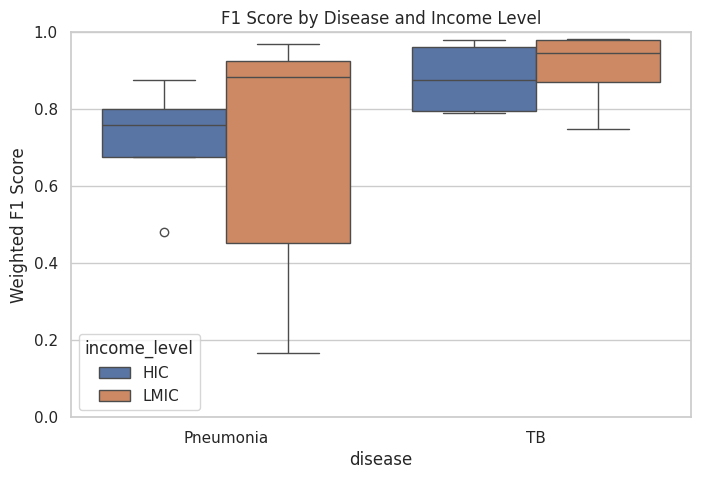

In [23]:
# ----------------------------------------
# BLOCK 3: BOXPLOT – DISEASE DIFFICULTY (TB vs PNEUMONIA)
# ----------------------------------------
# Ensure consistent categorical order
df['disease'] = pd.Categorical(df['disease'], categories=['Pneumonia', 'TB'], ordered=True)
df['income_level'] = pd.Categorical(df['income_level'], categories=['HIC', 'LMIC'], ordered=True)

# Pivot table: Mean F1 by disease and income level
pivot_disease = df.pivot_table(
    index='disease',
    columns='income_level',
    values='F1_score',
    aggfunc='mean',
    observed=False
)
print("Mean F1 Score by Disease and Income Level:\n")
print(pivot_disease.to_string())

# Full summary
summary_table = df.groupby(['disease', 'income_level'], observed=False)['F1_score'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()
print("\nFull Summary:\n")
print(summary_table.to_string(index=False))

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='disease', y='F1_score', hue='income_level', data=df)
plt.title("F1 Score by Disease and Income Level")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.show()

Training Time vs F1 Score Summary by Model and Income Level:

         model income_level  count     mean   median      min      max
   BaselineCNN          HIC      2 0.866039 0.866039 0.775246 0.956833
   BaselineCNN         LMIC      3 0.936040 0.925311 0.900133 0.982675
EfficientNetB0          HIC      2 0.635162 0.635162 0.480769 0.789555
EfficientNetB0         LMIC      3 0.416972 0.334417 0.166667 0.749832
   MobileNetV2          HIC      2 0.928823 0.928823 0.877126 0.980519
   MobileNetV2         LMIC      3 0.936508 0.927585 0.912446 0.969494
      ResNet50          HIC      2 0.768566 0.768566 0.741086 0.796047
      ResNet50         LMIC      3 0.780088 0.868014 0.491698 0.980554

Pivoted Mean F1 Score by Model and Income Level:

income_level         HIC      LMIC
model                             
BaselineCNN     0.866039  0.936040
EfficientNetB0  0.635162  0.416972
MobileNetV2     0.928823  0.936508
ResNet50        0.768566  0.780088


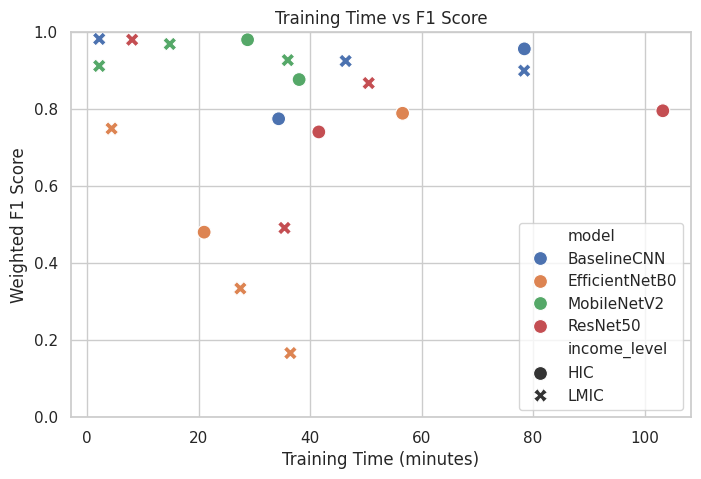

In [24]:
# ----------------------------------------
# BLOCK 4: SCATTERPLOT – TRAINING TIME VS F1 SCORE
# ----------------------------------------
# Prepare data
df_plot = df.dropna(subset=['training_time', 'F1_score'])
df_plot['income_level'] = pd.Categorical(df_plot['income_level'], categories=['HIC','LMIC'], ordered=True)
df_plot['model'] = pd.Categorical(df_plot['model'], categories=sorted(df['model'].unique()), ordered=True)

# Summary table
summary_table = df_plot.groupby(['model', 'income_level'], observed=False)['F1_score'].agg(['count','mean','median','min','max']).reset_index()
print("Training Time vs F1 Score Summary by Model and Income Level:\n")
print(summary_table.to_string(index=False))

# Pivot table
pivot_table = df_plot.pivot_table(
    index='model',
    columns='income_level',
    values='F1_score',
    aggfunc='mean',
    observed=False
)
print("\nPivoted Mean F1 Score by Model and Income Level:\n")
print(pivot_table.to_string())

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='training_time',
    y='F1_score',
    hue='model',
    style='income_level',
    data=df_plot,
    s=100
)
plt.title("Training Time vs F1 Score")
plt.xlabel("Training Time (minutes)")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.show()

Best model per dataset:
                       dataset        model  F1_score
1     dataset1 - Pneumonia HIC  MobileNetV2  0.877126
15           dataset2 - TB HIC  MobileNetV2  0.980519
5      dataset3 - Nigeria LMIC  MobileNetV2  0.969494
11          dataset4 - TB LMIC  BaselineCNN  0.982675
18  dataset5 - Bangladesh LMIC  MobileNetV2  0.927585


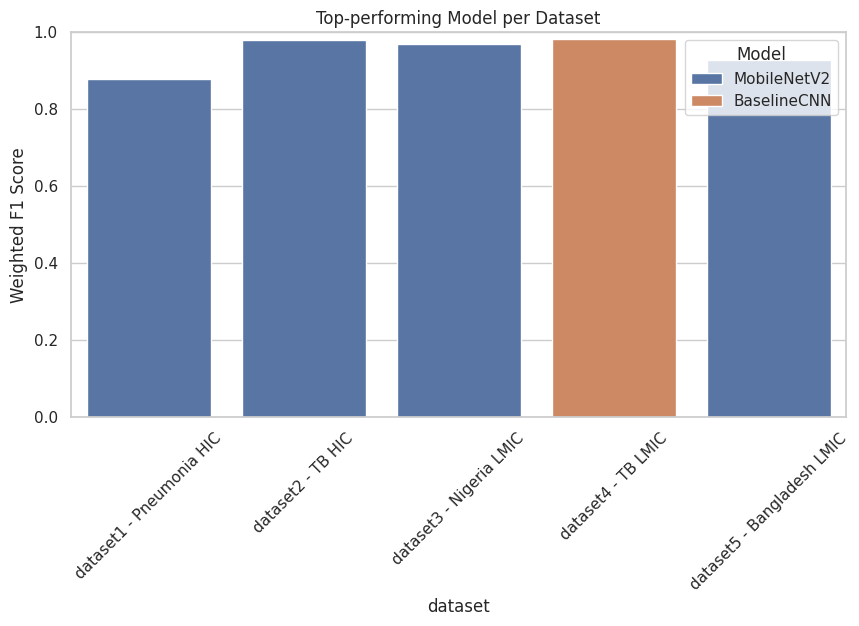

In [25]:
# ----------------------------------------
# BLOCK 5: BEST MODEL PER DATASET
# ----------------------------------------
# Ensure consistent dataset order
df['dataset'] = pd.Categorical(
    df['dataset'],
    categories=[
        'dataset1 - Pneumonia HIC',
        'dataset2 - TB HIC',
        'dataset3 - Nigeria LMIC',
        'dataset4 - TB LMIC',
        'dataset5 - Bangladesh LMIC'  # Updated
    ],
    ordered=True
)

# Find best model per dataset
best_model_idx = df.groupby('dataset', observed=False)['F1_score'].idxmax()
best_models = df.loc[best_model_idx, ['dataset', 'model', 'F1_score']]
print("Best model per dataset:")
print(best_models)

# Visualize
plt.figure(figsize=(10,5))
sns.barplot(
    x='dataset',
    y='F1_score',
    hue='model',
    data=df.loc[best_model_idx]
)
plt.title("Top-performing Model per Dataset")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.show()

Overall Best Model: dataset     dataset4 - TB LMIC
model              BaselineCNN
F1_score              0.982675
Name: 11, dtype: object
LMIC Best Model: dataset     dataset4 - TB LMIC
model              BaselineCNN
F1_score              0.982675
Name: 11, dtype: object


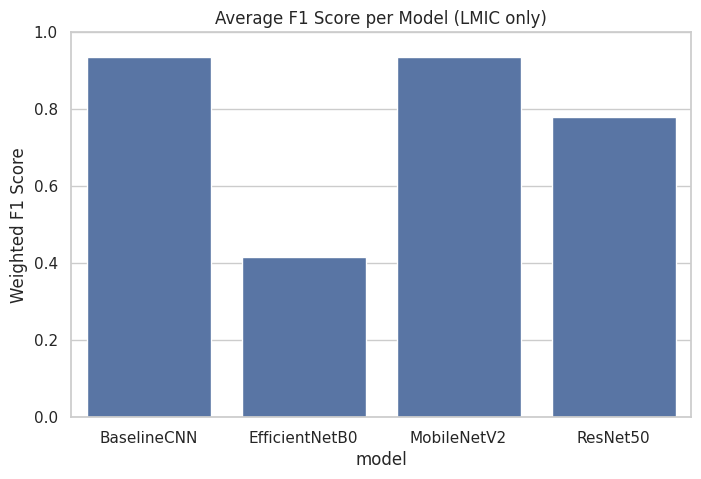

In [26]:
# ----------------------------------------
# BLOCK 6: BEST MODEL OVERALL & LMIC-SPECIFIC
# ----------------------------------------
# Overall best model
overall_best_idx = df['F1_score'].idxmax()
overall_best = df.loc[overall_best_idx, ['dataset', 'model', 'F1_score']]
print("Overall Best Model:", overall_best)

# LMIC best model
lmic_df = df[df['income_level'] == 'LMIC']
lmic_best_idx = lmic_df['F1_score'].idxmax()
lmic_best = lmic_df.loc[lmic_best_idx, ['dataset', 'model', 'F1_score']]
print("LMIC Best Model:", lmic_best)

# Average F1 per model in LMIC
lmic_summary = lmic_df.groupby('model')['F1_score'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='model', y='F1_score', data=lmic_summary)
plt.title("Average F1 Score per Model (LMIC only)")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.show()

In [27]:
# ----------------------------------------
# BLOCK: SUMMARIZE NUMBER OF IMAGES PER DATASET
# ----------------------------------------
# Updated dataset order (without dataset_chestxray2017)
dataset_order = [
    "dataset1_chest_xray_pneumonia",
    "dataset2_tb_chest_xray",
    "dataset3_nigeria_chest_xray",
    "dataset_tb_chest_xray",
    "Bangladesh_chest_xray"  # This will be dataset5
]

unique_datasets = {}

# Loop through JSON files
for fname in sorted(os.listdir(results_folder)):
    if fname.endswith('.json'):
        file_path = os.path.join(results_folder, fname)
        with open(file_path, 'r') as f:
            data = json.load(f)
        dataset = data.get("dataset_name")

        # Skip the duplicate dataset
        if dataset == "dataset_chestxray2017":
            continue

        if dataset not in unique_datasets:
            unique_datasets[dataset] = {
                "train": data.get("num_images_train", 0),
                "val": data.get("num_images_val", 0),
                "test": data.get("num_images_test", 0)
            }

# Create DataFrame
df_images = pd.DataFrame.from_dict(unique_datasets, orient='index').reset_index()
df_images.rename(columns={"index": "dataset"}, inplace=True)

# Assign dataset IDs (1-5)
df_images["dataset_id"] = [f"dataset{i+1}" for i in range(len(df_images))]
df_images["order"] = df_images["dataset"].apply(lambda x: dataset_order.index(x) if x in dataset_order else 99)
df_images = df_images.sort_values("order").drop(columns="order").reset_index(drop=True)

# Compute totals
df_images["total"] = df_images["train"] + df_images["val"] + df_images["test"]
df_images = df_images[["dataset_id", "dataset", "train", "val", "test", "total"]]

print(df_images.to_string(index=False))
print("Total images across all datasets:", df_images["total"].sum())

dataset_id                       dataset  train  val  test  total
  dataset1 dataset1_chest_xray_pneumonia   4434  782   624   5840
  dataset2        dataset2_tb_chest_xray   2939  630   631   4200
  dataset3   dataset3_nigeria_chest_xray   1362  291   297   1950
  dataset4         dataset_tb_chest_xray   2104  451   453   3008
  dataset5         Bangladesh_chest_xray   1690  423   513   2626
Total images across all datasets: 17624
